# Feature Extraction

In [6]:
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from tqdm import tqdm

OUT_DIR = Path("../outputs")
df = pd.read_csv(OUT_DIR / "inventory.csv")
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device :", device, "| images :", len(df))

Device : cpu | images : 1506


In [7]:
weights = ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()   # resize + center crop 224 + normalisation ImageNet
print(preprocess)

model = models.resnet50(weights=weights)
model.fc = nn.Identity()            # on retire la tête de classification -> sortie 2048-d
model.eval().to(device)
for p in model.parameters():        # on gèle tout
    p.requires_grad = False

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Paramètres entraînables :", n_trainable, "(doit être 0)")

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
Paramètres entraînables : 0 (doit être 0)


In [8]:
class ImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths); self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img)

ds = ImageDataset(df["path"].tolist(), preprocess)
# shuffle=False -> l'ordre des features correspondra exactement aux lignes de df
dl = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)

In [9]:
feats = []
with torch.no_grad():
    for batch in tqdm(dl, desc="Extraction"):
        out = model(batch.to(device))     # (B, 2048)
        feats.append(out.cpu().numpy())

features = np.concatenate(feats, axis=0)
np.save(OUT_DIR / "features.npy", features)

print("Shape features :", features.shape)         # attendu (1506, 2048)
print("Alignées avec df :", features.shape[0] == len(df))
print("NaN ?", np.isnan(features).any(), "| moyenne :", features.mean().round(3),
      "| écart-type :", features.std().round(3))

Extraction: 100%|██████████| 48/48 [00:47<00:00,  1.01it/s]

Shape features : (1506, 2048)
Alignées avec df : True
NaN ? False | moyenne : 0.101 | écart-type : 0.304


Images atypiques : 31 / 1506
split
unlabeled    31
dtype: int64


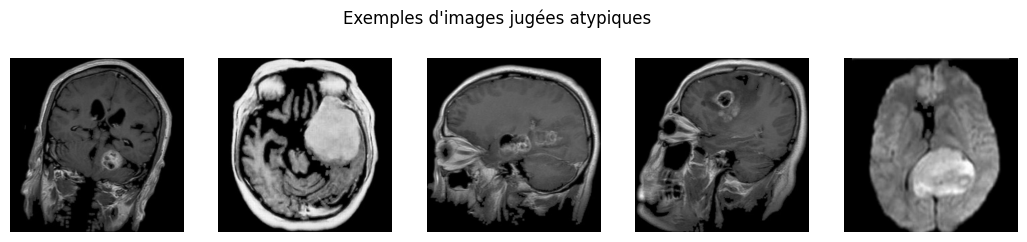

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np, pandas as pd

OUT_DIR = Path("../outputs")
X = np.load(OUT_DIR / "features.npy")
inv = pd.read_csv(OUT_DIR / "inventory.csv")
Xs = StandardScaler().fit_transform(X)

iso = IsolationForest(contamination=0.02, random_state=0)
inv["outlier"] = (iso.fit_predict(Xs) == -1)
print("Images atypiques :", int(inv["outlier"].sum()), "/", len(inv))
print(inv[inv["outlier"]].groupby("split").size())

flagged = inv[inv["outlier"]]["path"].tolist()[:5]
fig, ax = plt.subplots(1, len(flagged), figsize=(2.6*len(flagged), 2.8))
for a, p in zip(ax, flagged):
    a.imshow(Image.open(p)); a.axis("off")
fig.suptitle("Exemples d'images jugées atypiques"); plt.show()